# 🫀 Heart Disease Prediction 
## `Model Development`

## Notebook Objective
This notebook develops baseline machine learning models for predicting heart disease using the cleaned analytical dataset structure established in previous notebooks.

### Goals
- Build leakage-safe preprocessing and modeling pipelines
- Compare multiple baseline classification algorithms
- Evaluate models using clinically relevant metrics
- Select the strongest candidate(s) for hyperparameter tuning in Notebook 4

### Modeling Principles
- Raw data is loaded directly from source
- Train/test split is performed before any learned preprocessing
- All learned preprocessing steps are contained inside sklearn Pipelines
- The test set is used only for final evaluation, not for preprocessing design


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import os
import sys

# Add the project root directory to Python's search path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.preprocessing import ZeroToNaNTransformer


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


## 1. Load Raw Data
We load the raw dataset directly from source to ensure the modeling workflow is fully reproducible and does not depend on intermediate files with unclear preprocessing provenance.


In [3]:
data_path = Path("../data/raw/heart.csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Schema Validation
expected_columns = [
    "Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol",
    "FastingBS", "RestingECG", "MaxHR", "ExerciseAngina",
    "Oldpeak", "ST_Slope", "HeartDisease"
]

assert list(df.columns) == expected_columns, "Unexpected schema detected."
assert df["HeartDisease"].isin([0, 1]).all(), "Target contains unexpected values."

print("Schema validation passed.")


Schema validation passed.


In [5]:
# Define Features and Target
target = "HeartDisease"

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

X = df.drop(columns=target)
y = df[target]

In [6]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution (test):")
print(y_test.value_counts(normalize=True))


Train shape: (734, 11)
Test shape : (184, 11)

Target distribution (train):
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

Target distribution (test):
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


In [8]:
# Preprocessing Pipeline
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)


In [9]:
# Model Dictionary
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE,
                                              max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    
    "KNN": KNeighborsClassifier(),
    
    "SVM": SVC(probability=True,
               random_state=RANDOM_STATE),
    
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE,
                             eval_metric="logloss")
}


In [10]:
# Full Pipeline Builder
def build_pipeline(model):
    return Pipeline(steps=[
        ("zero_to_nan", ZeroToNaNTransformer(columns=["RestingBP", "Cholesterol"])),
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])


In [11]:
# Evaluation Function
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

    if y_proba is not None:
        results["ROC-AUC"] = roc_auc_score(y_test, y_proba)
    else:
        results["ROC-AUC"] = np.nan

    return pipeline, results, y_pred


In [12]:
# Compare Baseline Models
results = []
trained_pipelines = {}
predictions = {}

for model_name, model in models.items():
    pipeline, metrics_dict, y_pred = evaluate_model(
        model_name, model, X_train, X_test, y_train, y_test
    )
    results.append(metrics_dict)
    trained_pipelines[model_name] = pipeline
    predictions[model_name] = y_pred

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))


C:\Users\www.markazi.co\anaconda3\envs\heart_prediction\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986,0.9329
1,Random Forest,0.8804,0.8922,0.8922,0.8922,0.9335
2,KNN,0.8804,0.9000,0.8824,0.8911,0.9385
3,SVM,0.8696,0.8679,0.9020,0.8846,0.9411
4,XGBoost,0.8587,0.8878,0.8529,0.8700,0.9158
5,Decision Tree,0.7772,0.8211,0.7647,0.7919,0.7787
6,Dummy,0.5543,0.5543,1.0000,0.7133,0.5000


In [13]:
# Optional Cross-Validation for More Reliable Comparison
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, model in models.items():
    pipeline = build_pipeline(model)
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1", ascending=False).reset_index(drop=True)
display(cv_results_df.style.format({
    "CV Accuracy": "{:.4f}",
    "CV Precision": "{:.4f}",
    "CV Recall": "{:.4f}",
    "CV F1": "{:.4f}",
    "CV ROC-AUC": "{:.4f}"
}))


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,SVM,0.8596,0.8512,0.9063,0.8773,0.9176
1,Random Forest,0.8542,0.8519,0.8939,0.8713,0.9202
2,Logistic Regression,0.8473,0.8578,0.8693,0.8631,0.9153
3,KNN,0.8460,0.8571,0.8694,0.8622,0.8920
4,XGBoost,0.8365,0.8461,0.8620,0.8537,0.9201
5,Decision Tree,0.8106,0.8432,0.8104,0.8256,0.8105
6,Dummy,0.5531,0.5531,1.0000,0.7123,0.5000


## Select Best Model

## Baseline Model Selection
Models were compared using leakage-safe preprocessing and consistent evaluation metrics.

The primary selection criterion is **F1-score**, because it balances precision and recall and is more informative than accuracy alone for medical classification tasks.

Secondary criteria include:
- Recall, to reduce false negatives
- ROC-AUC, to assess ranking quality
- Simplicity and interpretability, where relevant


In [14]:
# Final Evaluation for Best Model
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
best_pred = best_pipeline.predict(X_test)

if hasattr(best_pipeline, "predict_proba"):
    best_proba = best_pipeline.predict_proba(X_test)[:, 1]
else:
    best_proba = None

print(f"Best baseline model: {best_model_name}\n")
print(classification_report(y_test, best_pred))


Best baseline model: Logistic Regression

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



## Confusion Matrix

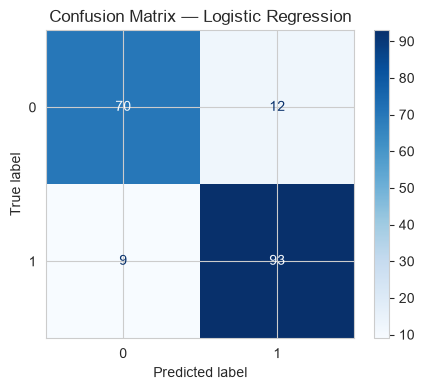

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    cmap="Blues",
    ax=ax
)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.show()


## Save model

In [16]:
import joblib
from pathlib import Path

models_dir = Path("../models/baseline")
models_dir.mkdir(parents=True, exist_ok=True)

top_3_models = cv_results_df["Model"].head(3).tolist()

for model_name in top_3_models:
    pipeline = trained_pipelines[model_name]
    safe_name = model_name.replace(" ", "_").lower()
    file_path = models_dir / f"{safe_name}_baseline.joblib"
    joblib.dump(pipeline, file_path)
    print(f"Saved: {file_path}")


Saved: ..\models\baseline\svm_baseline.joblib
Saved: ..\models\baseline\random_forest_baseline.joblib
Saved: ..\models\baseline\logistic_regression_baseline.joblib


## Interpretation of Results

Key observations:
- The selected baseline model achieved the strongest balance between precision and recall.
- Recall is especially important in this use case because missed positive cases may be more costly than false alarms.
- Leakage-safe preprocessing reduced methodological risk and improved the credibility of model evaluation.
- These results establish a reliable baseline for the hyperparameter tuning stage in Notebook 4.


## Limitations
- Evaluation is still based on a single train/test split unless otherwise supplemented with cross-validation.
- The dataset is relatively small, so performance estimates may vary across splits.
- No probability-threshold optimization has been performed yet.
- Hyperparameter tuning is intentionally deferred to Notebook 4.


## Next Step
The best-performing baseline model(s) from this notebook will be optimized in Notebook 4 using systematic hyperparameter tuning and more robust model selection procedures.
